In [1]:
from textblob import TextBlob
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jreynier.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jreynier.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jreynier.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\jreynier.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\jreynier.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet

True

In [2]:
import pandas as pd

try:
    df = pd.read_csv("amazon_review.csv")
except FileNotFoundError:
    reviews = [
        "This product is absolutely amazing! I love it so much. Best purchase ever.",
        "The features are fantastic and it works perfectly. Very well built.",
        "I am extremely happy with this purchase. Highly recommended to everyone!",
        "What a terrible experience. The product broke after just one use.",
        "This is the worst item I have ever bought. Complete waste of money.",
        "I was so disappointed. It didn't meet my expectations at all.",
        "It's okay, but nothing special. Could be better for the price.",
        "Good value for the price. I'm satisfied with what I got.",
        "The customer service was awful and unhelpful. Never buying again.",
        "Really impressed with the quality and performance! Great product.",
        "Meh, it's average. Does the job but nothing more.",
        "Absolutely love this! Works exactly as described. Five stars!",
        "Terrible quality. Broke within a week. I want a refund.",
        "Pretty decent for the price. Not perfect but good enough.",
        "Outstanding product. Exceeded my expectations in every way.",
        "Do not buy this. It's a scam. The product doesn't work at all.",
        "Nice design and easy to use. Would buy again.",
        "The packaging was damaged and the product had scratches on it.",
        "This is exactly what I needed. Simple, effective, and affordable.",
        "Very poor quality. I'm returning this immediately."
    ]
    df = pd.DataFrame({"review": reviews})

print(df.head())
print(f"Nombre de reviews : {len(df)}")

                                              review
0  This product is absolutely amazing! I love it ...
1  The features are fantastic and it works perfec...
2  I am extremely happy with this purchase. Highl...
3  What a terrible experience. The product broke ...
4  This is the worst item I have ever bought. Com...
Nombre de reviews : 20




1.   Can you perform a sentiment analysis on the collection of product reviews, classify each one as 'positive', 'negative', or 'neutral', and then generate a bar chart to visualize the distribution of these sentiments?"

2.   convert the text to lowercase, remove punctuation and numbers, filter out common stopwords, and then lemmatize the remaining words using their appropriate part-of-speech tags.
3. fter the text has been fully preprocessed and lemmatized, could you calculate the frequency of each unique word and then display a bar graph showing the top 15 most common words?
4. generate a word cloud based on the entire corpus of lemmatized review words to provide a visual summary of the most prominent terms.
5. Visualize the frequency of nouns, verbs, adjectives in this text.



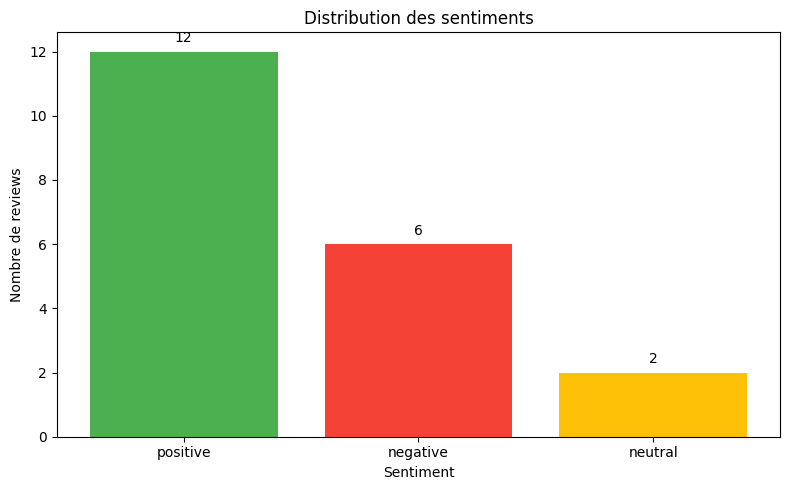

sentiment
positive     12
negative      6
neutral       2
Name: count, dtype: int64


In [3]:
from textblob import TextBlob
import matplotlib.pyplot as plt

text_col = [c for c in df.columns if 'review' in c.lower() or 'text' in c.lower()]
if text_col:
    text_col = text_col[0]
else:
    text_col = df.columns[0]

def classify_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.1:
        return 'positive'
    elif polarity < -0.1:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df[text_col].apply(classify_sentiment)

counts = df['sentiment'].value_counts()
colors = {'positive': '#4CAF50', 'neutral': '#FFC107', 'negative': '#F44336'}
plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color=[colors.get(s, 'gray') for s in counts.index])
plt.title("Distribution des sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Nombre de reviews")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), ha='center')
plt.tight_layout()
plt.show()

print(df[['sentiment']].value_counts())

In [4]:
import re
from nltk.corpus import stopwords
from textblob import Word

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    lemmatized = []
    blob = TextBlob(' '.join(words))
    for word, tag in blob.tags:
        pos = 'n'
        if tag.startswith('V'):
            pos = 'v'
        elif tag.startswith('J'):
            pos = 'a'
        elif tag.startswith('R'):
            pos = 'r'
        lemmatized.append(Word(word).lemmatize(pos))
    return ' '.join(lemmatized)

df['clean_text'] = df[text_col].apply(preprocess)
df[['clean_text']].head(10)

,clean_text
0,product absolutely amazing love much best purc...
1,feature fantastic work perfectly well build
2,extremely happy purchase highly recommend ever...
3,terrible experience product break one use
4,bad item ever buy complete waste money
5,disappointed didnt meet expectation
6,okay nothing special could better price
7,good value price im satisfy get
8,customer service awful unhelpful never buy
9,really impressed quality performance great pro...


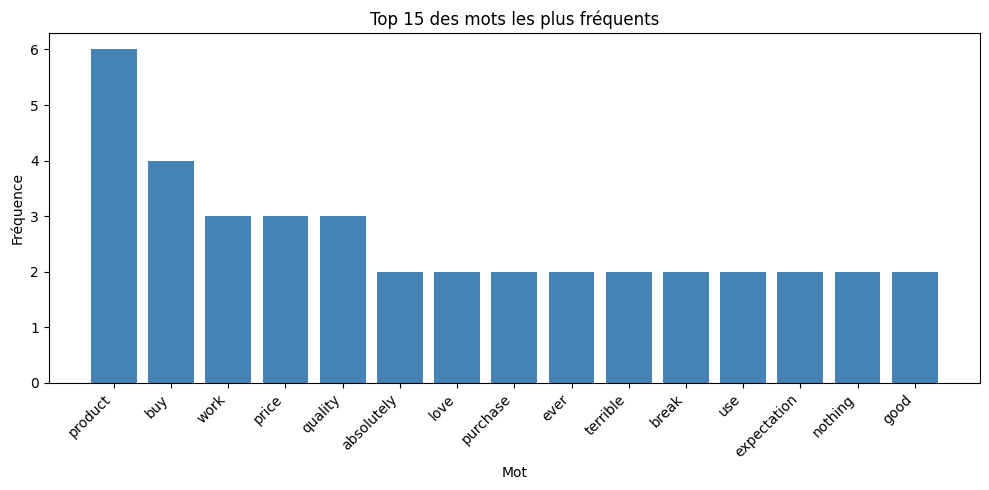

In [5]:
from collections import Counter

all_words = ' '.join(df['clean_text']).split()
word_counts = Counter(all_words)
top15 = word_counts.most_common(15)

words, freqs = zip(*top15)

plt.figure(figsize=(10, 5))
plt.bar(words, freqs, color='steelblue')
plt.title("Top 15 des mots les plus fréquents")
plt.xlabel("Mot")
plt.ylabel("Fréquence")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

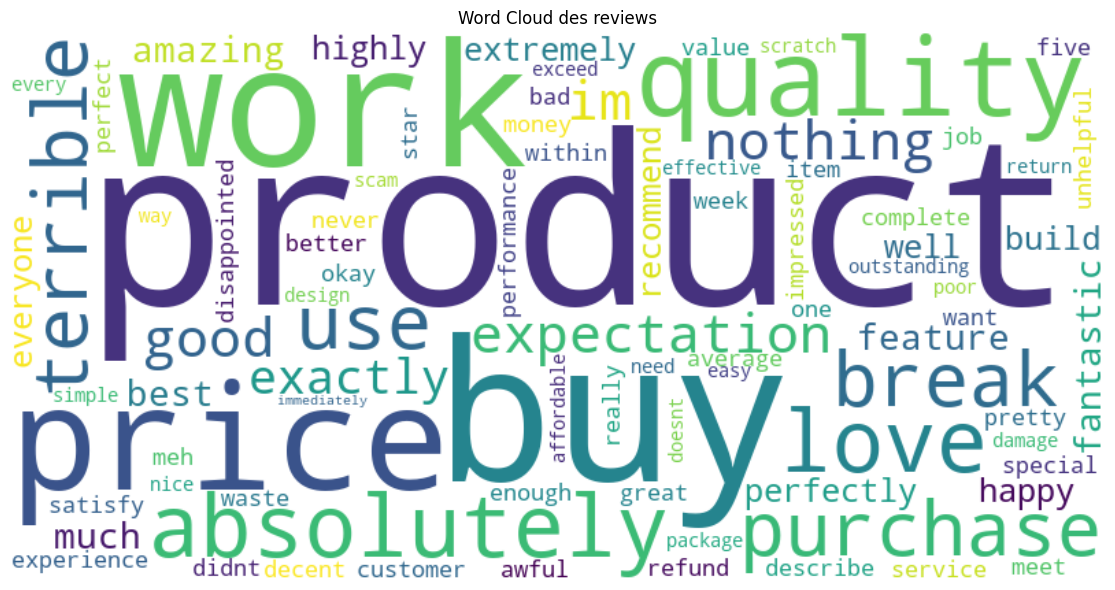

In [6]:
from wordcloud import WordCloud

corpus = ' '.join(df['clean_text'])

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='viridis', max_words=100).generate(corpus)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud des reviews")
plt.tight_layout()
plt.show()

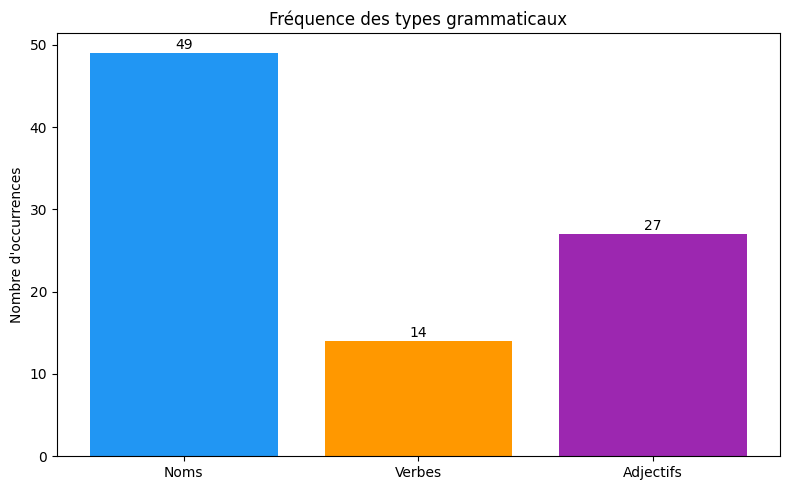

Top 5 noms : [('product', 6), ('work', 3), ('price', 3), ('quality', 3), ('purchase', 2)]
Top 5 verbes : [('buy', 4), ('build', 1), ('recommend', 1), ('break', 1), ('disappointed', 1)]
Top 5 adjectifs : [('terrible', 2), ('good', 2), ('amazing', 1), ('best', 1), ('fantastic', 1)]


In [7]:
from collections import Counter

all_clean = ' '.join(df['clean_text'])
blob_all = TextBlob(all_clean)

nouns = [word for word, tag in blob_all.tags if tag.startswith('NN')]
verbs = [word for word, tag in blob_all.tags if tag.startswith('VB')]
adjectives = [word for word, tag in blob_all.tags if tag.startswith('JJ')]

categories = ['Noms', 'Verbes', 'Adjectifs']
counts_pos = [len(nouns), len(verbs), len(adjectives)]

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, counts_pos, color=['#2196F3', '#FF9800', '#9C27B0'])
plt.title("Fréquence des types grammaticaux")
plt.ylabel("Nombre d'occurrences")
for bar, val in zip(bars, counts_pos):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center')
plt.tight_layout()
plt.show()

print("Top 5 noms :", Counter(nouns).most_common(5))
print("Top 5 verbes :", Counter(verbs).most_common(5))
print("Top 5 adjectifs :", Counter(adjectives).most_common(5))